In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
sys.path.append('../../')
import numpy as np
import torch
from model.MinAggGNN import MinAggGNN
import matplotlib.pyplot as plt

device = torch.device('cuda')
L = 2
m = 2
eta = 0.0003
epochs = 20000
seed = 0

model = MinAggGNN(2, 8, L, 2, edge_dim = 1)
state_dict = torch.load(f'../model_progress/parallel/seed_{seed}/model_final.pt')
checkpoints = torch.load(f'../model_progress/parallel/seed_{seed}/model_checkpoints.pt')
model.load_state_dict(state_dict)
model.eval()
model.to(device)

c:\Users\heje197\AppData\Local\miniconda3\envs\minar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MinAggGNN(2, 2, num_layers=2)

In [3]:
from MINAR.ComputationGraph import ComputationGraph, Circuit
from model.CustomLosses import MultiplicativeLoss, JointLoss
import torch_geometric as pyg
import networkx as nx

G = ComputationGraph(model)
G.add_inputs({'edge_attr' : [1, model.convs[0].agg_mlp.lins[0].weight[:,-1]],
              'input_self.0' : [3, model.convs[0].up_mlp.lins[0].weight[:,-2]],
              'input_self.1' : [3, model.convs[0].up_mlp.lins[0].weight[:,-1]]})
G.add_residual_connections({'edge_attr' : [5, model.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
G.add_residual_connections({4 : [7, model.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})
G.number_of_edges()

18432

In [4]:
test_loss = MultiplicativeLoss()
mse_loss = torch.nn.MSELoss()
bce_loss = torch.nn.BCEWithLogitsLoss()
criterion = JointLoss([mse_loss, bce_loss], [False, True], weight=torch.tensor([1.,25.], device=device))

test_data = torch.load('../data/test_data.pt', map_location=device, weights_only=False)
test_loader = pyg.loader.DataLoader(test_data, batch_size = len(test_data))
num_reachable_test_nodes = sum([data.reachable.sum() for data in test_loader])
for data in test_data:
    data.x = torch.cat([data.x, data.x_bfs], 1)

corrupted_data = torch.load('../data/test_data.pt', map_location=device, weights_only=False)
for data_corr in corrupted_data:
    data_corr.x = torch.cat([data_corr.x, data_corr.x_bfs], 1)
    data_corr.x = torch.zeros_like(data_corr.x, device=device)
    data_corr.edge_attr = torch.zeros_like(data_corr.edge_attr, device=device)

G.calculate_scores(test_data, corrupted_data, criterion, which = 'weight_grad')
G.calculate_scores(test_data, corrupted_data, criterion, which = 'EAP')
G.calculate_scores(test_data, corrupted_data, criterion, which = 'EAP-IG', steps=20)

In [5]:
# which = 'weight'
# which = 'EAP'
which = 'EAP-IG'
K = 11
C = Circuit(model, G, K=K, key=which)

print(C.number_of_edges())

for data in test_loader:
    out = C.forward(data)
    mul_circuit_loss = float(test_loss(out[:,0][data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    bfs_accuracy = ((out[:,1].flatten() > 0) == data.reachable).sum().item() / data.num_nodes
    print(f'Circuit Test Loss: {mul_circuit_loss:.4f}, Test Acc: {bfs_accuracy:.4f}')

11
Circuit Test Loss: 0.0499, Test Acc: 0.9831


In [6]:
test_loader = pyg.loader.DataLoader(test_data, batch_size = len(test_data))
criterion = MultiplicativeLoss()
num_reachable_test_nodes = sum([data.reachable.sum() for data in test_loader])
for data in test_loader:
    out = C.ablate_circuit(data)
    mul_circuit_loss = float(test_loss(out[:,0][data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    bfs_accuracy = ((out[:,1].flatten() > 0) == data.reachable).sum().item() / data.num_nodes
    print(f'Ablated Test Loss: {mul_circuit_loss:.4f}, Test Acc: {bfs_accuracy:.4f}')

Ablated Test Loss: 58038.1680, Test Acc: 0.8161


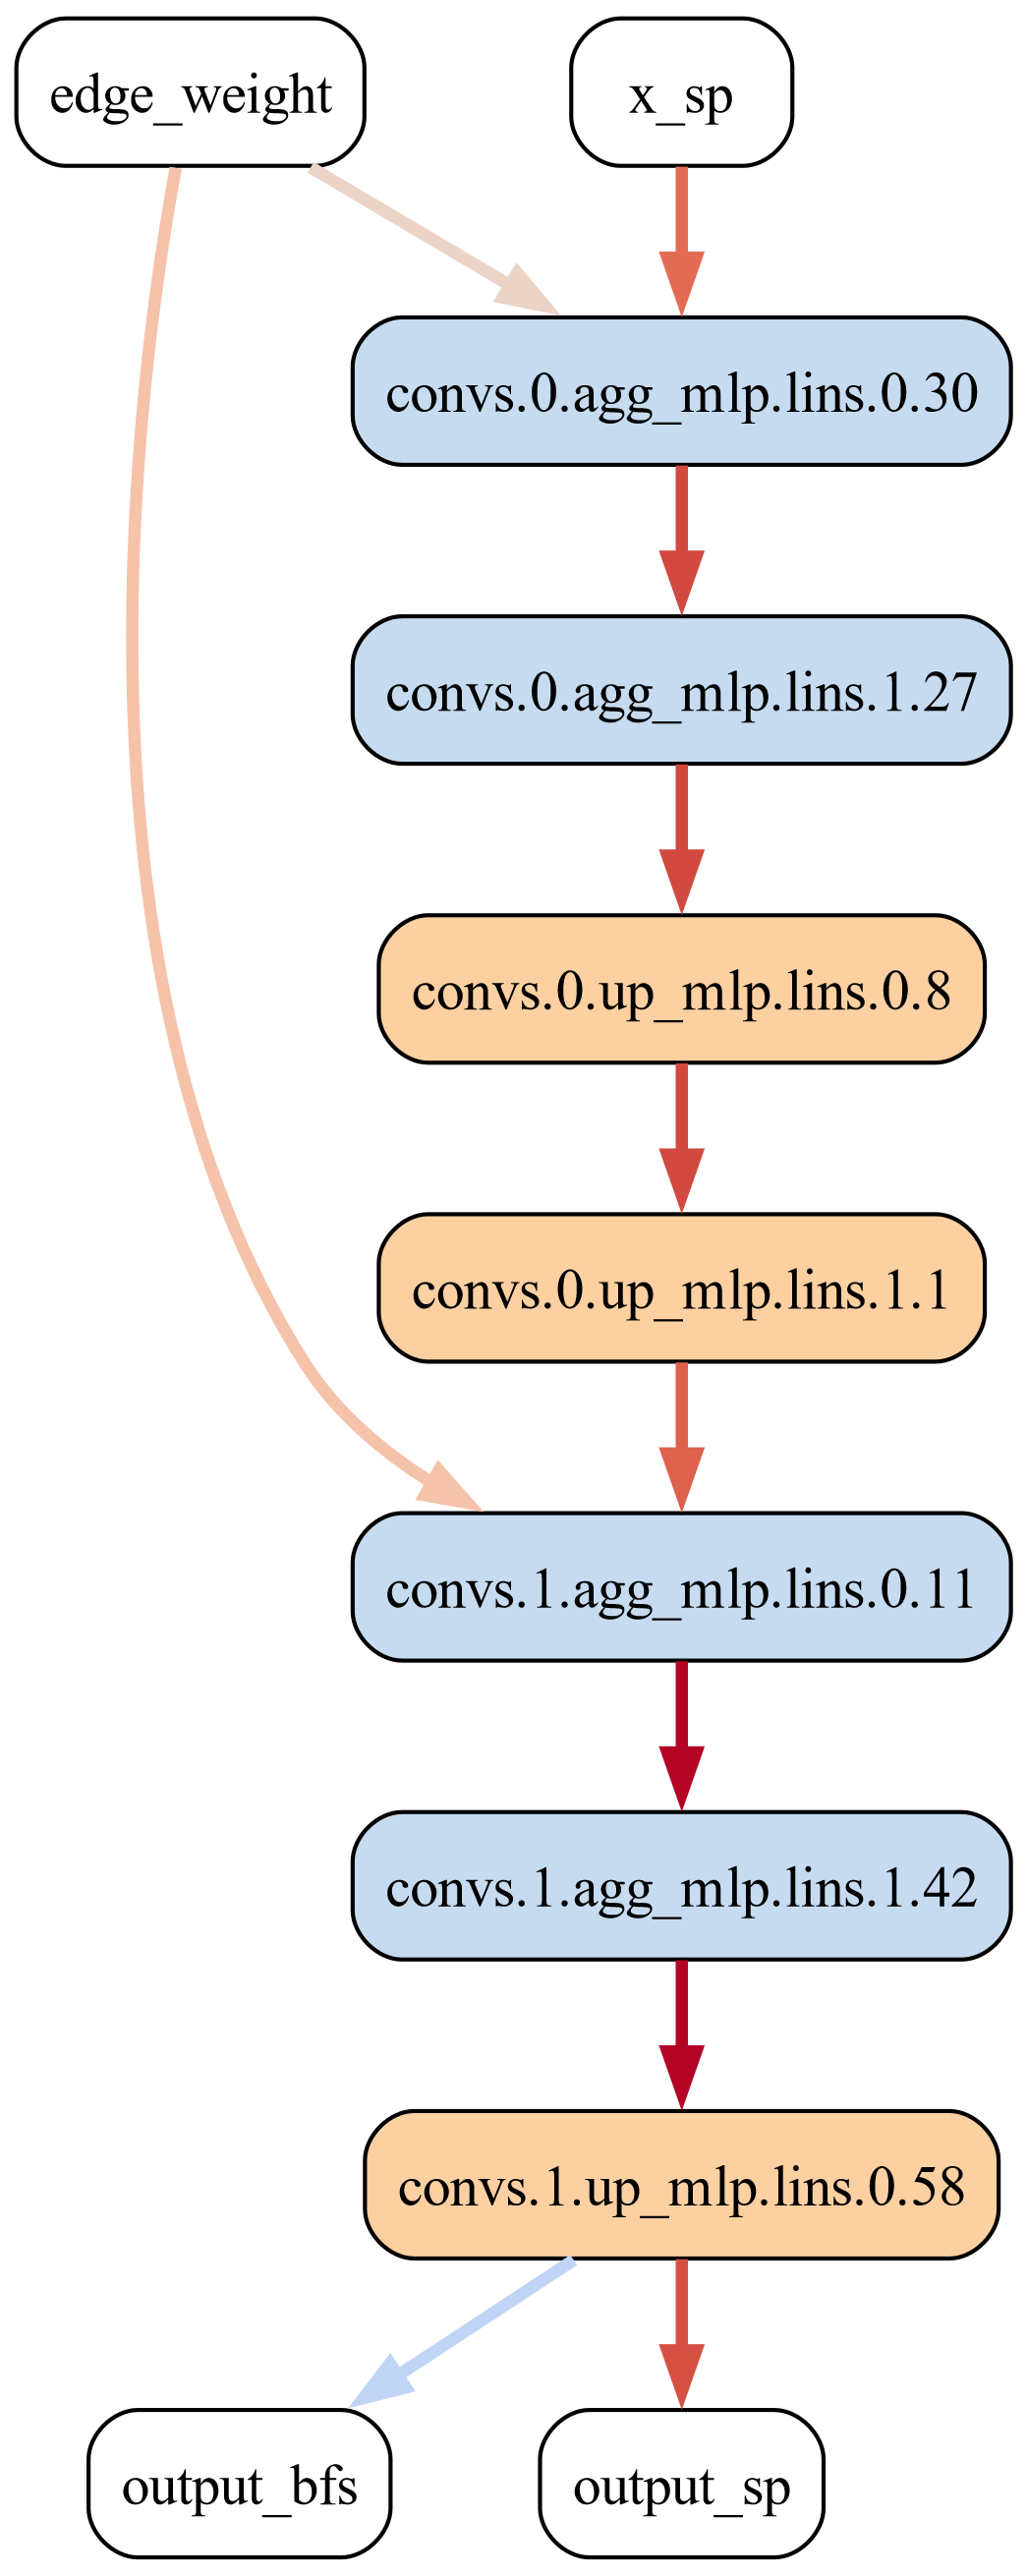

In [7]:
from IPython.display import display
from PIL import Image

from matplotlib import colors, cm

plt.rcParams['font.family'] = 'serif'
nx.relabel_nodes(C, {C.layers[-1][1] : 'output_sp',
                     C.layers[-1][0] : 'output_bfs',
                     'input.0' : 'x_sp',
                     'edge_attr' : 'edge_weight'}, copy=False)
C.layers[0] = ['x_sp', 'edge_weight']
C.layers[-1] = ['output_sp', 'output_bfs']

C_pydot = nx.nx_agraph.to_agraph(C)
C_pydot.node_attr['shape'] = 'Mrecord'
C_pydot.node_attr['style'] = 'filled'

layer_colors = ['white', '#c6dbef', '#c6dbef', '#fdd0a2', '#fdd0a2', '#c6dbef', '#c6dbef', '#fdd0a2', 'white']
node_colors = {node : layer_colors[layer] for node, layer in nx.get_node_attributes(C, 'layer').items()}
for v in C_pydot.nodes():
    node = C_pydot.get_node(v)
    node.attr['fillcolor'] = node_colors[node]
    # node.attr['pos'] = f'{20*c_pos[node][0]},{4*c_pos[node][1]}!'

edge_cmap=plt.cm.coolwarm
_, circuit_edge_weights = zip(*nx.get_edge_attributes(C,'weight').items())
abs_vmax = abs(max(circuit_edge_weights, key=abs))
normalized_weights = {edge : weight / (2*abs_vmax) + 0.5 for edge, weight in nx.get_edge_attributes(C,'weight').items()}
for u,v in C_pydot.edges():
    edge = C_pydot.get_edge(u,v)
    edge.attr['color'] = colors.to_hex(edge_cmap(normalized_weights[edge]))
    edge.attr["penwidth"] = 3.0

inputs = C_pydot.add_subgraph(name='inputs')
inputs.add_nodes_from(C.layers[0])
inputs.graph_attr['rank'] = 'source'

# C_pydot.graph_attr['rankdir']='LR'
C_pydot.graph_attr['nodesep'] = '0.5'
C_pydot.graph_attr['dpi'] = 300
C_pydot.draw(f"../images/parallel_circuit_seed_{seed}.pdf", prog="dot")
C_pydot.draw(f"../images/parallel_circuit_seed_{seed}.png", prog="dot")
C_pydot.write(f"../dot_files/parallel_circuit_seed_{seed}.dot")
display(Image.open(f"../images/parallel_circuit_seed_{seed}.png"))

C:\Users\heje197\AppData\Local\Temp\ipykernel_20360\3475217486.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


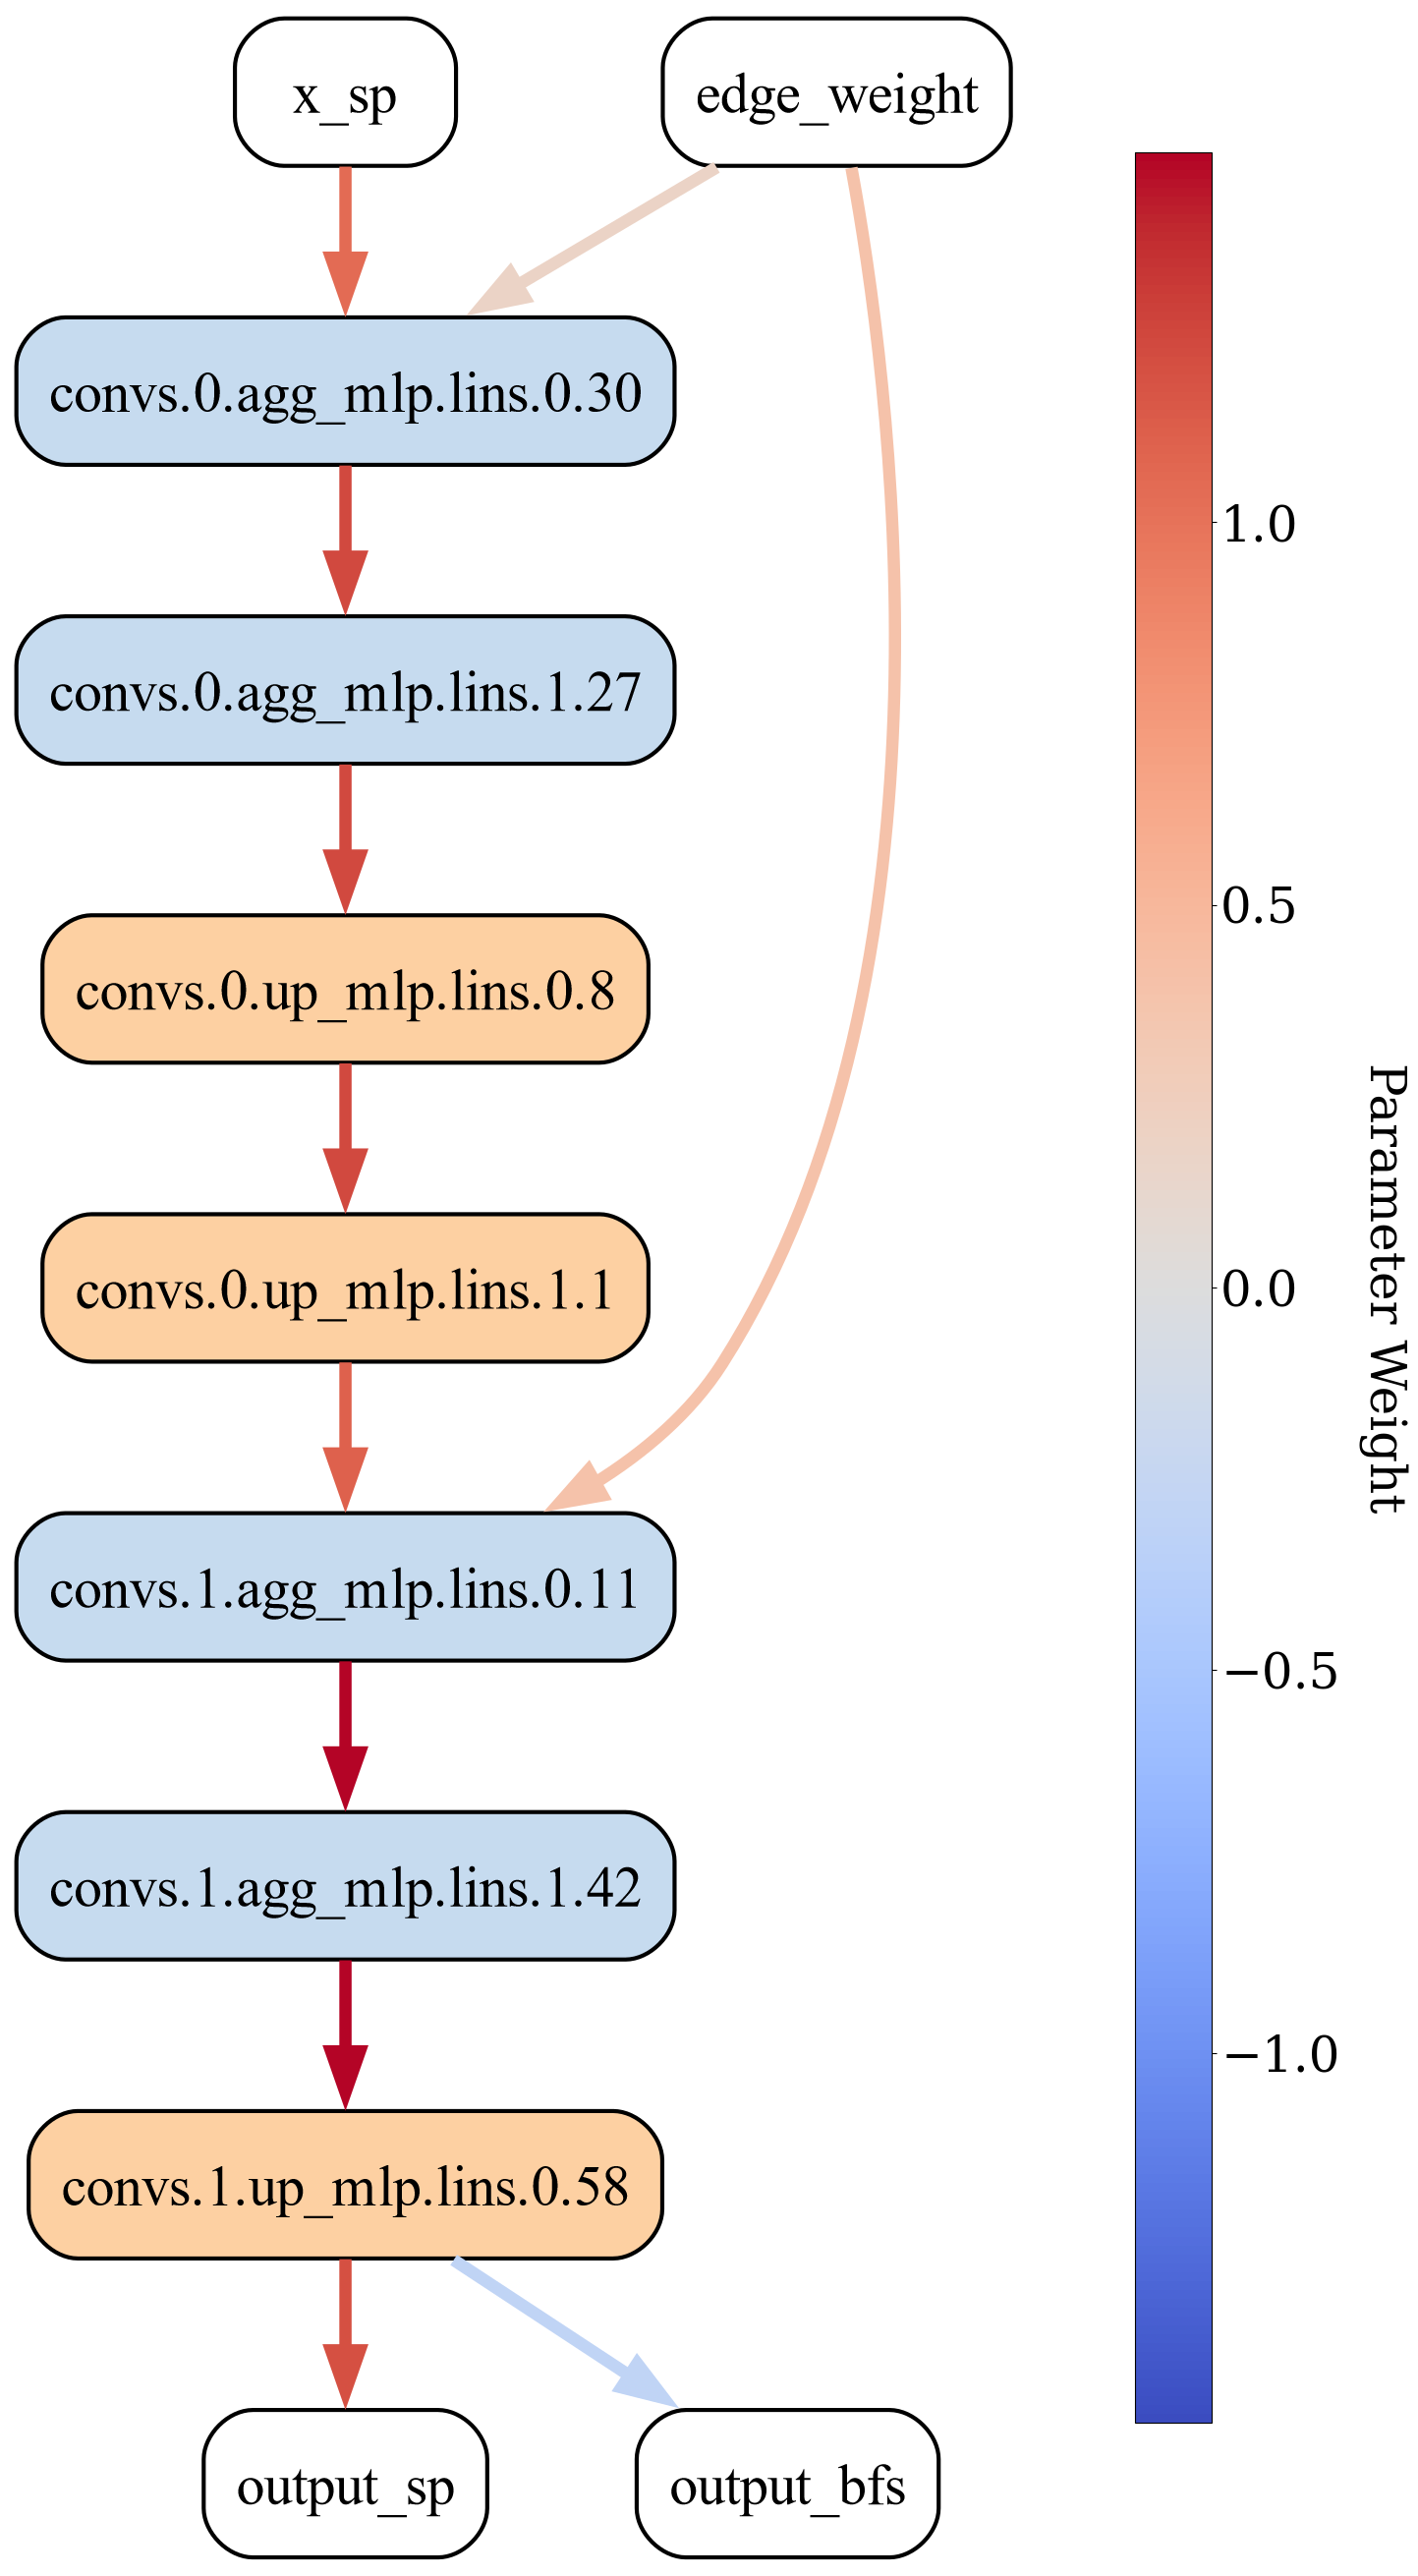

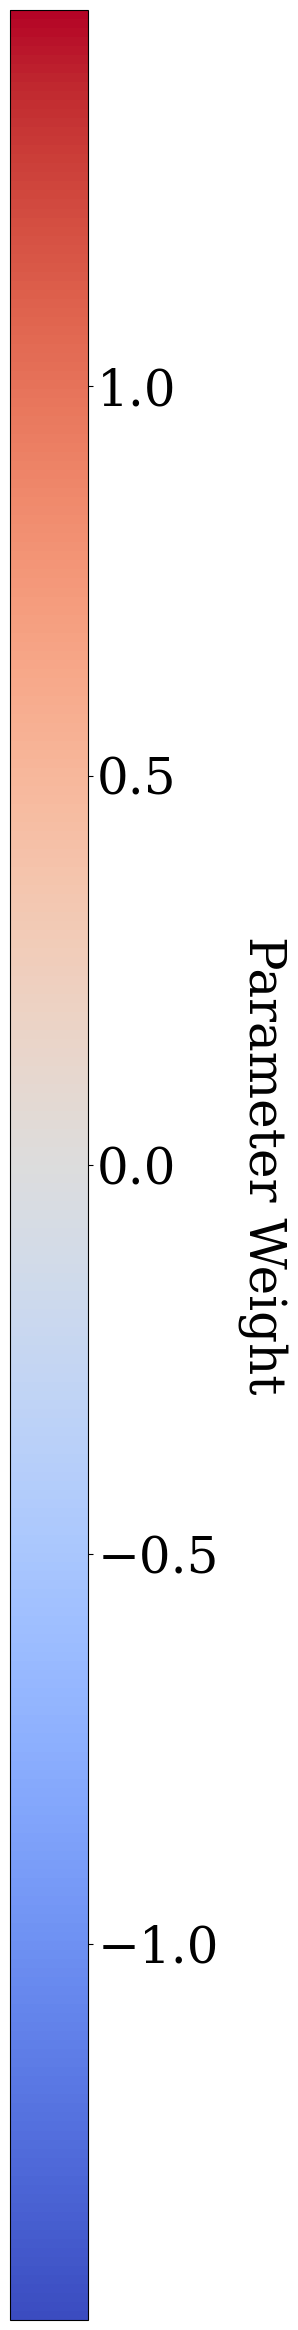

In [7]:
import matplotlib
# create and display a standalone colorbar for the circuit edge colors    
matplotlib.rcParams.update({'font.size':36})
max_edge_weight = max(circuit_edge_weights, key=abs)
vmin, vmax = -float(max_edge_weight), float(max_edge_weight)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap=edge_cmap, norm=norm)
sm.set_array([])

fig_cb, ax_cb = plt.subplots(figsize=(1, 30))
fig_cb.colorbar(sm, cax=ax_cb, orientation='vertical').set_label('Parameter Weight', rotation=270, labelpad=50)
plt.tight_layout()
plt.savefig(f"../images/parallel_circuit_colorbar_seed_{seed}.pdf", bbox_inches='tight')
plt.savefig(f"../images/parallel_circuit_colorbar_seed_{seed}.png", bbox_inches='tight')

circuit_image = Image.open(f"../images/parallel_circuit_seed_{seed}.png")
colorbar_image = Image.open(f"../images/parallel_circuit_colorbar_seed_{seed}.png")
colorbar_y = (circuit_image.height - colorbar_image.height) // 2
padding = 100
combined_w = circuit_image.width + padding + colorbar_image.width
combined_image = Image.new('RGBA', (combined_w, circuit_image.height), (255, 255, 255, 255))

combined_image.paste(circuit_image, (0, 0))
combined_image.paste(colorbar_image, (circuit_image.width + padding, colorbar_y))

combined_image = combined_image.convert('RGB')  # drop alpha for saving/display
combined_image.save(f"../images/parallel_circuit_with_colorbar_seed_{seed}.png", dpi=(300,300))
display(combined_image)

In [ ]:
C = Circuit(model, G, K=K, key=which)
mse_loss = torch.nn.MSELoss()

l1_regs = torch.load(f'../model_progress/parallel/seed_{seed}/l1_regs.pt')
test_losses = torch.load(f'../model_progress/parallel/seed_{seed}/test_losses.pt')
test_accs = torch.load(f'../model_progress/parallel/seed_{seed}/test_accs.pt')
mse_losses = torch.load(f'../model_progress/parallel/seed_{seed}/mse_losses.pt')

checkpoints = torch.load(f'../model_progress/parallel/seed_{seed}/model_checkpoints.pt')
try:
    circuit_losses = torch.load(f'../model_progress/parallel/seed_{seed}/circuit_losses.pt')
    circuit_mse_losses = torch.load(f'../model_progress/parallel/seed_{seed}/circuit_mse_losses.pt')
    circuit_l1_norms = torch.load(f'../model_progress/parallel/seed_{seed}/circuit_l1_norms.pt')
    print('Loaded existing circuit progress data.')
except:
    circuit_losses = []
    circuit_mse_losses = []
    circuit_accuracy = []
    circuit_l1_norms = torch.zeros(len(checkpoints))
    for i, checkpoint in enumerate(checkpoints):
        model.load_state_dict(checkpoint)
        C.model_state_dict = checkpoint
        for data in test_loader:
            G_tmp = ComputationGraph(model)
            G_tmp.add_inputs({'edge_attr' : [1, model.convs[0].agg_mlp.lins[0].weight[:,-1]],
                'input_self.0' : [3, model.convs[0].up_mlp.lins[0].weight[:,-2]],
                'input_self.1' : [3, model.convs[0].up_mlp.lins[0].weight[:,-1]]})
            G_tmp.add_residual_connections({'edge_attr' : [5, model.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
            G_tmp.add_residual_connections({4 : [7, model.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})
            for e in C.edges:
                circuit_l1_norms[i] += float(G_tmp.edges[e]['weight'])

            out = C.forward(data)
            mul_circuit_loss = criterion(out[:,0][data.reachable].flatten(), data.y[data.reachable]).detach() / num_reachable_test_nodes
            circuit_mse_loss = mse_loss(out[:,0][data.reachable].flatten(), data.y[data.reachable]).detach() / num_reachable_test_nodes
            circuit_mse_losses.append(float(circuit_mse_loss))
            bfs_accuracy = ((out[:,1].flatten() > 0) == data.reachable).sum().item() / data.num_nodes
            circuit_losses.append(float(mul_circuit_loss))
            circuit_accuracy.append(float(bfs_accuracy))
    torch.save(circuit_losses, f'../model_progress/parallel/seed_{seed}/circuit_losses.pt')
    torch.save(circuit_accuracy, f'../model_progress/parallel/seed_{seed}/circuit_accuracy.pt')
    torch.save(circuit_mse_losses, f'../model_progress/parallel/seed_{seed}/circuit_mse_losses.pt')
    torch.save(circuit_l1_norms, f'../model_progress/parallel/seed_{seed}/circuit_l1_norms.pt')

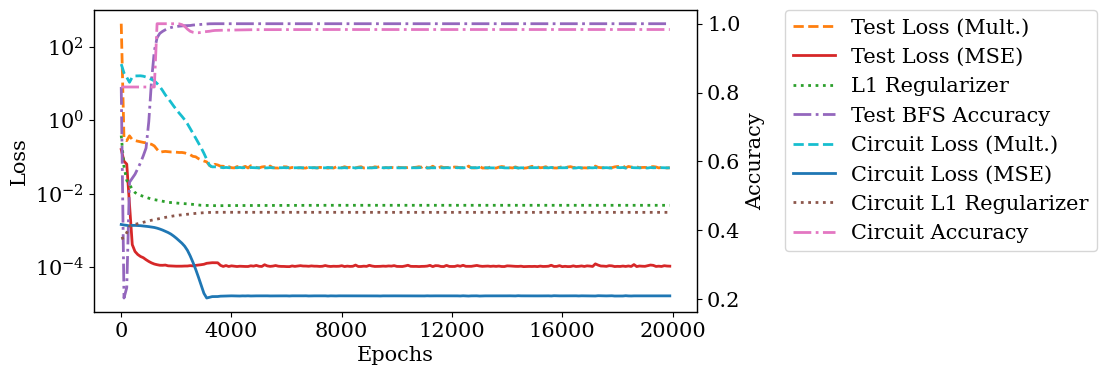

In [9]:
plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = 'serif'
plt.rcParams['lines.linewidth'] = 2

epochs = len(test_losses)
num_ticks = 5

fig, ax = plt.subplots(1,1, figsize = (8,4))
ax.plot(test_losses[0:epochs:100].detach(), label='Test Loss (Mult.)', color='tab:orange', ls='dashed')
ax.plot(mse_losses[0:epochs:100].detach(), label='Test Loss (MSE)', color='tab:red', ls='solid')
ax.plot((eta * l1_regs)[0:epochs:100].detach(), label='L1 Regularizer', color='tab:green', ls='dotted')

ax3 = ax.twinx()
ax3.plot(test_accs[0:epochs:100].detach(), label='Test BFS Accuracy', color='tab:purple', ls='dashdot')

ax2 = ax.twiny()
ax2.plot(circuit_losses, color='tab:cyan', label='Circuit Loss (Mult.)', ls='dashed')
ax2.plot(circuit_mse_losses, color='tab:blue', label='Circuit Loss (MSE)', ls='solid')
ax2.plot(eta * circuit_l1_norms, color='tab:brown', label='Circuit L1 Regularizer', ls='dotted')
ax4 = ax3.twiny()
ax4.plot(circuit_accuracy, color='tab:pink', label='Circuit Accuracy', ls='dashdot')

ax3.set_xticks([])
ax2.set_xticks([])
ax4.set_xticks([])

ax.set_xticks(range(0, len(circuit_losses)+1, len(circuit_losses) // num_ticks))
ax.set_xticklabels(range(0, epochs+1, epochs // num_ticks))
ax.set_xlabel('Epochs')

ax.set_yscale('log')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax3.set_ylabel('Accuracy')

fig.legend(bbox_to_anchor=(1.4, .97), loc='upper right')
plt.savefig(f"../images/parallel_circuit_grokking_seed_{seed}.pdf", bbox_inches='tight')
plt.savefig(f"../images/parallel_circuit_grokking_seed_{seed}.png", bbox_inches='tight', dpi=300)
plt.tight_layout()

In [ ]:
from tqdm import tqdm
criterion = MultiplicativeLoss()
mse_criterion = torch.nn.MSELoss()
score_methods = ['weight', 'weight_grad', 'EAP', 'EAP-IG']
circuit_test_losses = {score : [] for score in score_methods}
circuit_bfs_accuracy = {score : [] for score in score_methods}
circuit_losses_ablate = {score : [] for score in score_methods}
circuit_accuracy_ablate = {score : [] for score in score_methods}
actual_node_count = {score : [] for score in score_methods}
actual_edge_count = {score : [] for score in score_methods}
pbar = tqdm(range(50))
for K in pbar:
    for score in score_methods:
        for data in test_loader:
            C_tmp = Circuit(model, G, K=K, key=score)
            out = C_tmp.forward(data)
            out_ablate = C_tmp.ablate_circuit(data)
            mul_circuit_loss = float(criterion(out[:,0][data.reachable].flatten(), data.y[data.reachable]).detach()) / len(test_data)
            bfs_accuracy = ((out[:,1].flatten() > 0) == data.reachable).sum().item() / data.num_nodes
            mul_circuit_loss_ablate = float(criterion(out_ablate[:,0][data.reachable].flatten(), data.y[data.reachable]).detach()) / len(test_data)
            bfs_accuracy_ablate = ((out_ablate[:,1].flatten() > 0) == data.reachable).sum().item() / data.num_nodes
            circuit_test_losses[score].append(mul_circuit_loss)
            circuit_bfs_accuracy[score].append(bfs_accuracy)
            circuit_losses_ablate[score].append(mul_circuit_loss_ablate)
            circuit_accuracy_ablate[score].append(bfs_accuracy_ablate)
            actual_node_count[score].append(C_tmp.number_of_nodes())
            actual_edge_count[score].append(C_tmp.number_of_edges())

100%|██████████| 50/50 [06:05<00:00,  7.31s/it]


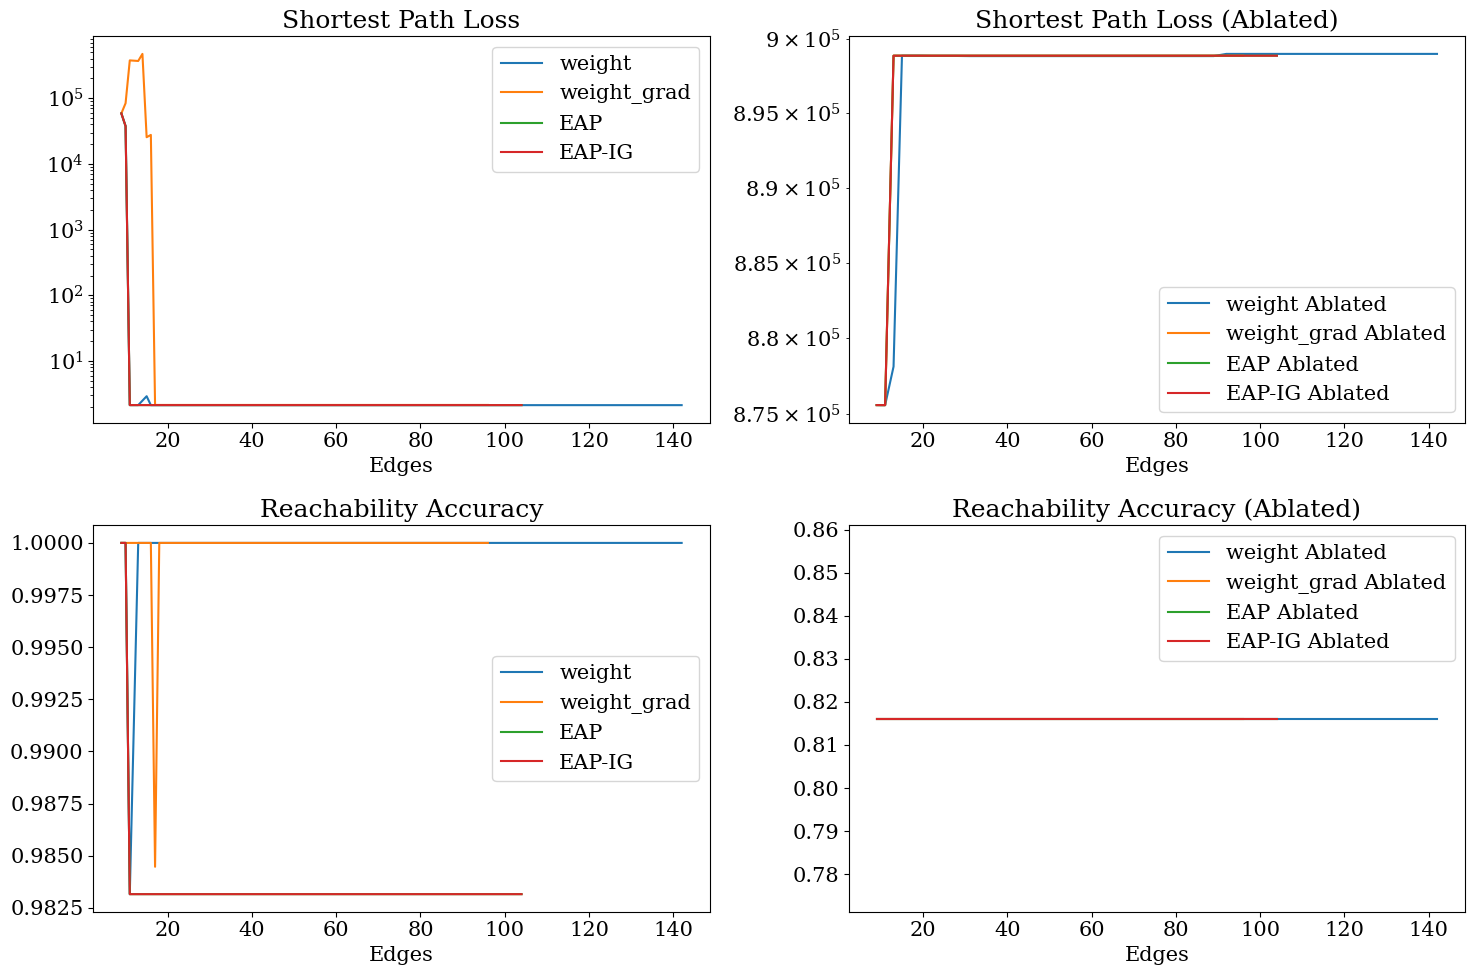

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
for score in score_methods:
    ax[0,0].plot(actual_edge_count[score], circuit_test_losses[score], label=f'{score}')
    ax[0,1].plot(actual_edge_count[score], circuit_losses_ablate[score], label=f'{score} Ablated')
ax[0,0].set_yscale('log')
ax[0,0].set_title('Shortest Path Loss')
ax[0,0].set_xlabel('Edges')
ax[0,1].set_yscale('log')
ax[0,1].set_title('Shortest Path Loss (Ablated)')
ax[0,1].set_xlabel('Edges')
for score in score_methods:
    ax[1,0].plot(actual_edge_count[score], circuit_bfs_accuracy[score], label=f'{score}')
    ax[1,1].plot(actual_edge_count[score], circuit_accuracy_ablate[score], label=f'{score} Ablated')
ax[1,0].set_title('Reachability Accuracy')
ax[1,0].set_xlabel('Edges')
ax[1,1].set_title('Reachability Accuracy (Ablated)')
ax[1,1].set_xlabel('Edges')
ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()
plt.tight_layout()